In [15]:
from pathlib import Path
import datetime
import sys
import scipy.integrate
import scipy.signal
import random
import math
from scipy.fft import fft, ifft

%config InlineBackend.figure_format='retina'
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

import matplotlib as mpl
import matplotlib.font_manager as fm
from pathlib import Path
plt.rcParams['font.family'] = 'sans-serif'
def get_super(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    super_s = "ᴬᴮᶜᴰᴱᶠᴳᴴᴵᴶᴷᴸᴹᴺᴼᴾQᴿˢᵀᵁⱽᵂˣʸᶻᵃᵇᶜᵈᵉᶠᵍʰᶦʲᵏˡᵐⁿᵒᵖ۹ʳˢᵗᵘᵛʷˣʸᶻ⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻⁼⁽⁾"
    res = x.maketrans(''.join(normal), ''.join(super_s))
    return x.translate(res)
def get_sub(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    sub_s = "ₐ₈CDₑբGₕᵢⱼₖₗₘₙₒₚQᵣₛₜᵤᵥwₓᵧZₐ♭꜀ᑯₑբ₉ₕᵢⱼₖₗₘₙₒₚ૧ᵣₛₜᵤᵥwₓᵧ₂₀₁₂₃₄₅₆₇₈₉₊₋₌₍₎"
    res = x.maketrans(''.join(normal), ''.join(sub_s))
    return x.translate(res)


In [14]:
#loading Errors in Areas from errors in intensities
f = open("240911_CuAl2O3_100ppm_JDN2_28_CO_400_450_71mW_200s5s_splitBest_Fit2000_2200V3.txt", "r")
reports_list=f.readlines()
f.close()
print(reports_list[1].replace("\n","").replace(".","").isdigit())
stringtest = "05"
print(stringtest.isdecimal())
times= []
i=-1
for line in reports_list:
    if line.replace("\n","").replace(".","").isdigit():
        i+=1
        times.append([])
        times[i].append(float(line.replace("\n","")))      
    if "amplitude" in line and "init" in line and "%" in line:
        short = line[line.find("(")+1: line.find("%")]
        times[i].append(short)


print(times)
df_errors = pd.DataFrame(times)
columns = ["times"]
for i in range(len(df_errors.columns)-1):
    columns.append("lz"+str(i+1)+"_")
print(columns)

False
True
[[2.5], [7.5], [12.5], [17.5], [22.5], [27.5], [32.5], [37.5], [42.5], [47.5], [52.5, '32.84', '16.95'], [57.5], [62.5], [67.5], [72.5], [77.5], [82.5], [87.5], [92.5], [97.5], [102.5], [107.5], [112.5], [117.5], [122.5], [127.5], [132.5], [137.5, '10.24', '6.16'], [142.5], [147.5], [152.5], [157.5], [162.5], [167.5], [172.5], [177.5], [182.5], [187.5]]
['times', 'lz1_', 'lz2_']


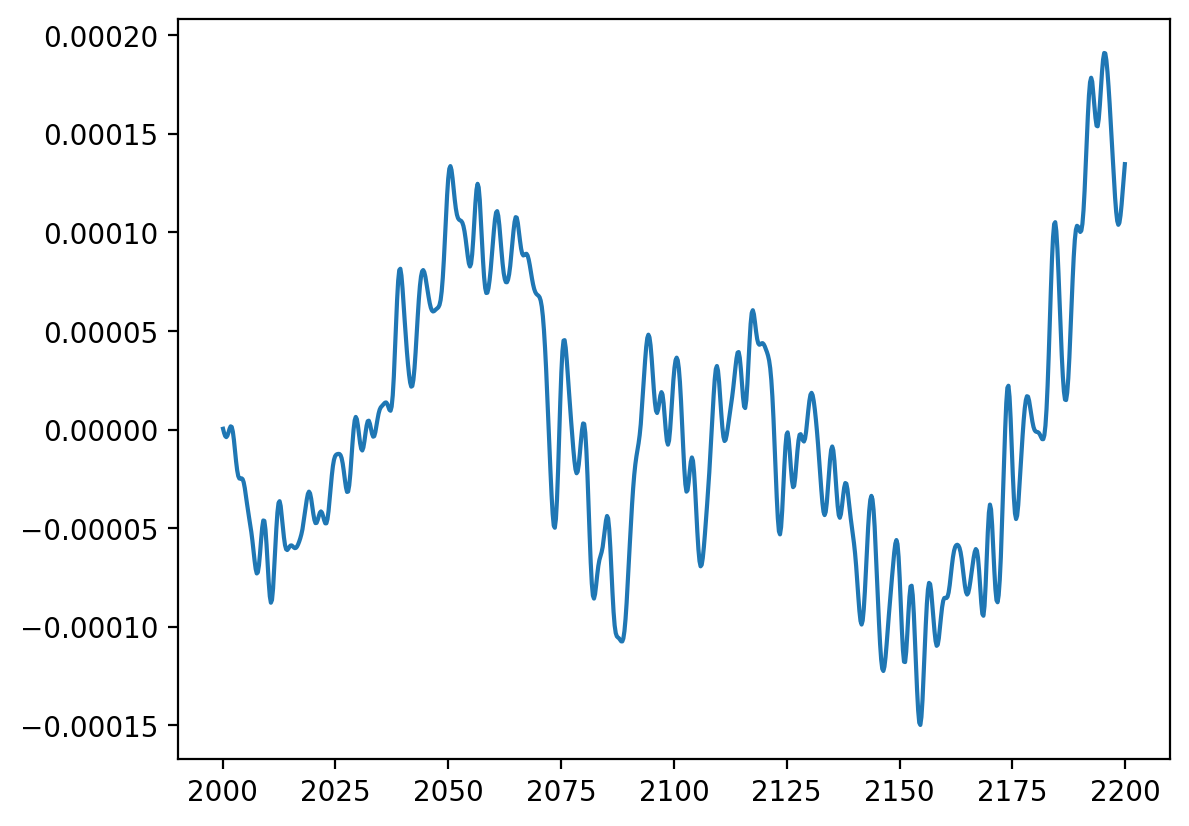

In [20]:
#loading from errors in residuals
for time in df_data.index.get_level_values(0):
    ydat = df_data.loc[time].loc["ydat",:]
    best_fit = df_data.loc[time].loc["best fit",:]
    residuals = ydat-best_fit
plt.plot(df_data.loc[2.5].loc["xdat",:],residuals)

In [127]:
csv_filename = '240911_CuAl2O3_100ppm_JDN2_28_CO_550_600_124mW_200s_2nd5s_splitBest_Fit_Values2000_2200V3'
df_data = pd.read_csv(csv_filename+".csv",index_col=[0,1])

In [17]:
# Load data from fit values
csv_filename = 'FTIR_241107_CuAl2O3_Reduce_500ppmCO_400450nm_77mW_200s5s_splitBest_Fit1900_2150V4' #this is the only line that needs to be modified
df_data = pd.read_csv(csv_filename+".csv",index_col=[0,1])
#Collating Areas
dft_areas = df_data.loc[pd.IndexSlice[:,"areas"],:].rename(columns=df_data.loc[pd.IndexSlice[2.5,"names"],:])
dft_areas = dft_areas.set_index(dft_areas.index.get_level_values(0))
#dft_locations
dft_locations = df_data.loc[pd.IndexSlice[:,"locations"],:].rename(columns=df_data.loc[pd.IndexSlice[2.5,"names"],:])
dft_locations = dft_locations.set_index(dft_locations.index.get_level_values(0))
#dft_FWHM
dft_FWHM = df_data.loc[pd.IndexSlice[:,"FWHM"],:].rename(columns=df_data.loc[pd.IndexSlice[2.5,"names"],:])
dft_FWHM = dft_FWHM.set_index(dft_FWHM.index.get_level_values(0))
#Collating Area errors
dft_areas_error = df_data.loc[pd.IndexSlice[:,"areas_error"],:].rename(columns=df_data.loc[pd.IndexSlice[2.5,"names"],:])
dft_areas_error = dft_areas_error.set_index(dft_areas_error.index.get_level_values(0))

print(df_data)
print(csv_filename)

                                       0                       1  \
102.5 names                         lz1_                    lz2_   
      locations                   2099.9                  2114.7   
      FWHM                          15.1                    12.4   
      areas          0.01006515779368522    0.004035902779256473   
      areas_error  7.097671484932635e-05   6.364948958110282e-05   
...                                  ...                     ...   
197.5 names                         lz1_                    lz2_   
      locations                   2099.9                  2114.7   
      FWHM                          15.1                    12.4   
      areas        -0.009613889387644625  -0.0037299166615722967   
      areas_error  7.212760194471941e-05   6.468156549698485e-05   

                                        2                       3  \
102.5 names                          lz3_                    lz4_   
      locations                    2125.0    

In [18]:
#Making new array
cond = "400_450"
dft_areas = pd.concat([dft_areas], keys=[cond])
dft_locations = pd.concat([dft_locations], keys=[cond])
dft_FWHM = pd.concat([dft_FWHM], keys=[cond])
dft_areas_error = pd.concat([dft_areas_error], keys=[cond])
print(dft_areas)
#Adding on the next ones
try:
    df_areas
except NameError:
    df_areas =dft_areas
    df_locations =dft_locations
    df_FWHM =dft_FWHM
    df_areas_error =dft_areas_error
else:
    df_areas =pd.concat([df_areas, dft_areas]).astype(float)
    df_locations =pd.concat([df_locations, dft_locations])
    df_FWHM =pd.concat([df_FWHM, dft_FWHM])
    df_areas_error =pd.concat([df_areas_error, dft_areas_error]).astype(float)
df_locations = df_locations.sort_index().astype(float)
df_areas = df_areas.sort_index().astype(float)
df_FWHM = df_FWHM.sort_index().astype(float)
df_areas_error = df_areas_error.sort_index().astype(float)
print(df_areas)

                                 lz1_                    lz2_  \
400_450 102.5     0.01006515779368522    0.004035902779256473   
        2.5     -0.010065157793707757   -0.004035902779240486   
        7.5      -0.00968984853530852   -0.003966589150224187   
        12.5    -0.009011658868941064  -0.0037468144396451963   
        17.5    -0.008107403273976965  -0.0034778499796049855   
        22.5     -0.00716917947982143  -0.0031135727328324148   
        27.5    -0.006074618897939921  -0.0026307962276552743   
        32.5    -0.004983446816956283   -0.002195138513913397   
        37.5    -0.003985410691529356  -0.0017716237122331613   
        42.5    -0.002903225706493595  -0.0013938759264244815   
        47.5   -0.0018787442454185621  -0.0010901042930352434   
        52.5   -0.0008217918454886952  -0.0006772654611515438   
        57.5   0.00033060292570330496  -0.0002322265539149715   
        62.5    0.0015486968842552962  0.00020801781752144421   
        67.5     0.002775

In [31]:
peak = "lz1_"
#df_FWHM = df_FWHM.astype(float)
for space in df_areas.index.get_level_values(0).unique():
    mean_FW = np.mean(df_FWHM.loc[pd.IndexSlice[space,2.5:97.5],peak].to_numpy())
    mean_FW2 = np.mean(df_FWHM.loc[pd.IndexSlice[space,102.5:197.5],peak].to_numpy())
    print(space + ": "+str(mean_FW) + ":"+str(mean_FW2))
    print(df_areas.loc[space,:].shape)
#print(df_FWHMtest.loc[(space,slice(2.5,7.5)),peak].to_numpy())

400_450: 15.100000000000003:15.100000000000003
(40, 7)
450_500: 15.100000000000003:15.100000000000003
(40, 7)
500_550: 15.100000000000003:15.100000000000003
(40, 7)
550_600: 15.100000000000003:15.100000000000003
(40, 7)
550_600_2nd: 15.100000000000003:15.100000000000003
(40, 7)
600_650: 15.100000000000003:15.100000000000003
(40, 7)


In [32]:
dropkey = "650_700"
df_areas = df_areas.drop(dropkey)
df_locations = df_locations.drop(dropkey)
df_FWHM= df_FWHM.drop(dropkey)
df_areas_error = df_areas_error.drop(dropkey)

In [34]:
peak = "lz1_"
#df_FWHM = df_FWHM.astype(float)
df_locations = df_locations.sort_index().astype(float)
for space in df_areas.index.get_level_values(0).unique():
    mean_loc = np.mean(df_locations.loc[pd.IndexSlice[space,2.5:47.5],peak].to_numpy())
    mean_loc2 = np.mean(df_locations.loc[pd.IndexSlice[space,52.5:97.5],peak].to_numpy())
    print(space + ": "+str(mean_loc) + ":"+str(mean_loc2))
print(df_areas.index.get_level_values(0).unique())
#print(df_FWHMtest.loc[(space,slice(2.5,7.5)),peak].to_numpy())

450_500: 2099.9000000000005:2099.9000000000005
500_550: 2099.9000000000005:2099.9000000000005
550_600: 2099.9000000000005:2099.9000000000005
550_600_2nd: 2099.9000000000005:2099.9000000000005
600_650: 2099.9000000000005:2099.9000000000005
650_700: 2099.9000000000005:2099.9000000000005
Index(['450_500', '500_550', '550_600', '550_600_2nd', '600_650', '650_700'], dtype='object')


In [38]:
print(df_areas.index.get_level_values(0))



Index(['400_450', '400_450', '400_450', '400_450', '400_450', '400_450',
       '400_450', '400_450', '400_450', '400_450',
       ...
       '600_650', '600_650', '600_650', '600_650', '600_650', '600_650',
       '600_650', '600_650', '600_650', '600_650'],
      dtype='object', length=240)


In [31]:
np.mean(np.absolute(df_areas.loc[slice("550_600",:],"lz1_"].to_numpy
print

0.018893419157594217

In [116]:
df_areas.loc[(slice("550_600","550_600_2nd"),slice(2.5)),:]

,,lz1_,lz2_,lz3_,lz4_,lz5_,lz6_,lz7_
550_600,2.5,-0.016924,-0.005503,-0.003768,-0.000953,-0.014354,-0.010482,-0.004733
550_600_2nd,2.5,-0.031732,-0.013483,-0.009935,-0.001142,-0.015787,-0.012357,-0.004976


{'lz1_': 0.30997598503086665, 'lz2_': 0.40130484917530934, 'lz3_': 0.4299591293078593, 'lz4_': 0.1819002974151013, 'lz5_': 0.18567189818510163, 'lz6_': 0.1923352144189355, 'lz7_': 0.16627933624887548}
400_450
{'lz1_': 0.01620213434065358, 'lz2_': 0.006520870521131666, 'lz3_': 0.004202008656881752, 'lz4_': 0.0009571653757745399, 'lz5_': 0.028736965136279803, 'lz6_': 0.020559456032333175, 'lz7_': 0.008948595986282535}
450_500
{'lz1_': 0.021512876659882756, 'lz2_': 0.007931653657021327, 'lz3_': 0.004564015701917096, 'lz4_': 0.0020150372267599436, 'lz5_': 0.02341454457623493, 'lz6_': 0.018001659759707318, 'lz7_': 0.009196210371153427}
500_550
{'lz1_': 0.0298180121309126, 'lz2_': 0.011882479808379086, 'lz3_': 0.00837044814003735, 'lz4_': 0.0017466618838601303, 'lz5_': 0.021179873582519125, 'lz6_': 0.01636650853389001, 'lz7_': 0.007462451120924715}
550_600
{'lz1_': 0.019560582439925485, 'lz2_': 0.006625655483493207, 'lz3_': 0.004359147855509453, 'lz4_': 0.00149787041246987, 'lz5_': 0.0191234

C:\Users\jdnor\AppData\Local\Temp\ipykernel_32684\2061066844.py:60: FutureWarning: Starting with pandas version 3.0 all arguments of to_csv except for the argument 'path_or_buf' will be keyword-only.
  df_adj_areas.to_csv( "FTIR_241107_CuAl2O3_Reduce_200s5s_splitBest_Fit1900_2150V4_AreasAdj.csv",',')
C:\Users\jdnor\AppData\Local\Temp\ipykernel_32684\2061066844.py:61: FutureWarning: Starting with pandas version 3.0 all arguments of to_csv except for the argument 'path_or_buf' will be keyword-only.
  df_area_int.to_csv( "FTIR_241107_CuAl2O3_Reduce_200s5s_splitBest_Fit1900_2150V4_AreasAdjInt.csv",',')


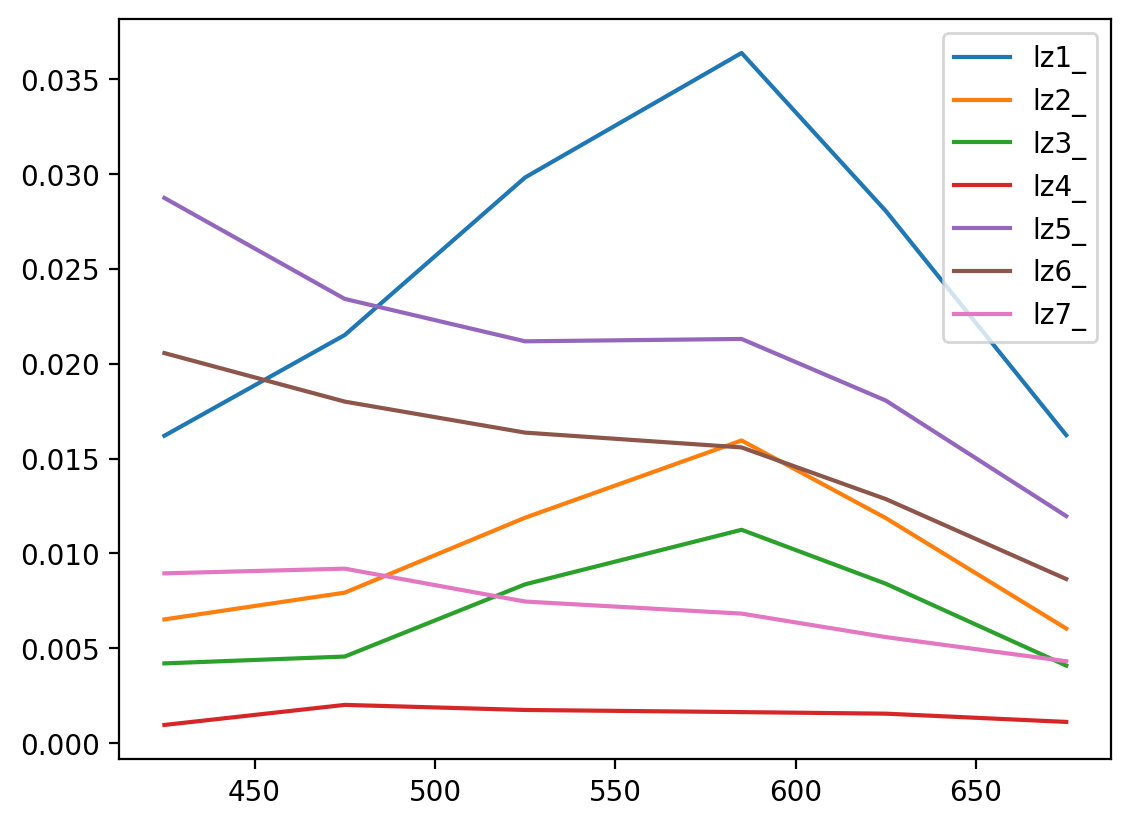

In [109]:
#Getting Area Maximums and Shifts

df_adj_areas =df_areas.copy()
area_shift = {}
area_int= {}
area_per = {}
area_int_error = {}
rate_of_red = {}
kernel_size = 3
kernel = np.ones(kernel_size) / kernel_size
powers = {"400_450":1.471,"450_500":1.270,"500_550":1.046,"550_600":1.059,"600_650":1.034,"650_700":1,"550_600_2nd":1.059}
order = {"400_450":3,"450_500":1,"500_550":5,"550_600":0,"600_650":6,"650_700":2,"550_600_2nd":7}
ss_per= {"lz1_":0.313,"lz2_":0.430,"lz3_":0.285}
ss_area= {"lz1_":0.187,"lz2_":0.261,"lz3_":0.159}
for peak in df_areas.columns:
    rate_of_red[peak] = (np.mean(np.absolute(df_areas.loc[pd.IndexSlice["550_600_2nd",:],peak].to_numpy()))/np.mean(np.absolute(df_areas.loc[pd.IndexSlice["550_600",:],peak].to_numpy())))/6
print(rate_of_red)
#area_int[space][peak] = powers[i]*2*np.mean(np.absolute(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()))
for space in df_areas.index.get_level_values(0).unique():
    area_shift[space] = {}
    area_int[space] = {}
    area_int_error[space] ={}
    area_per[space] = {}
    space_total = 0
    for peak in df_areas.columns:
        shift_loc = np.argmax(np.convolve(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy(),kernel, mode='same'))
        #shift_loc = np.argmin(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy())
        area_shift[space][peak] = df_areas.index.get_level_values(1)[shift_loc]
        #area_int[space][peak] = np.convolve(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy(),kernel, mode='same')[shift_loc]
        #area_int[space][peak] = 2*np.mean(np.absolute(df_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()))
       
        #Undoes
        df_adj_areas.loc[pd.IndexSlice[space,:],peak] = powers[space]*df_adj_areas.loc[pd.IndexSlice[space,:],peak] #-rate_of_red[peak]*order[space]
       
        area_int[space][peak] = 2*np.mean(np.absolute(df_adj_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()))
        df_area_int_ref=pd.DataFrame.from_dict(area_int)
        #area_int[space][peak] = powers[space]*2*area_int[space][peak]
        
        #area_int[space][peak] = area_int[space][peak]-rate_of_red[peak]*order[space]
        area_int_error[space][peak] = powers[space]*2*np.mean(np.absolute(df_areas_error.loc[pd.IndexSlice[space,:],peak].to_numpy()))
    print(space)
    print(area_int[space])
       
        #df_adj_areas.loc[pd.IndexSlice[space,:],peak] = powers[space]*df_areas.loc[pd.IndexSlice[space,:],peak]-rate_of_red[peak]*order[space]
    #for peak in df_areas.columns:
     #   space_total += area_int[space][peak]
    #for peak in df_areas.columns:
     #   area_per[space][peak] = 100*(area_int[space][peak]/ss_area[peak])
    #temp_shift = df_areas.loc[pd.IndexSlice[space,:],peak]
    
    #append([df_areas.loc[pd.IndexSlice[space,:],peak].reset_index( level = [0] ).drop(columns='level_0') ,space])

df_area_shift = pd.DataFrame.from_dict(area_shift)
df_area_int = pd.DataFrame.from_dict(area_int)
df_area_per = pd.DataFrame.from_dict(area_per)
#df_area_int_error = pd.DataFrame.from_dict(area_int_error).drop("550_600",axis=1)

#print(df_area_int_error)
#saving data
df_adj_areas.to_csv( "FTIR_241107_CuAl2O3_Reduce_200s5s_splitBest_Fit1900_2150V4_AreasAdj.csv",',')
df_area_int.to_csv( "FTIR_241107_CuAl2O3_Reduce_200s5s_splitBest_Fit1900_2150V4_AreasAdjInt.csv",',')
wl_dep_index = [[425,425,425],[475,475,475,],[525,525,525],[575,575,575],[585,585,585],[625,625,625],[675,675,675]]

df_area_int = df_area_int.rename(columns =  {"400_450":425,"450_500":475,"500_550":525,"550_600":575,"600_650":625,"650_700":675,"550_600_2nd":575,"550_600_2nd":585})
df_area_int =df_area_int.drop(575,axis=1).rename(columns={585:575})
df_adj_areas = df_adj_areas.rename(index =  {"400_450":425,"450_500":475,"500_550":525,"550_600":575,"600_650":625,"650_700":675,"550_600_2nd":575,"550_600_2nd":585})
df_adj_areas =df_adj_areas.drop(575,axis=0).rename(index={585:575})
#df_area_int_error = df_area_int_error.rename(columns =  {"400_450":425,"450_500":475,"500_550":525,"550_600":575,"600_650":625,"650_700":675,"550_600_2nd":585})

plt.plot(df_area_int.transpose(),label= df_area_int.index)
#print(df_areas.loc[pd.IndexSlice[:,12.5],:])
#plt.plot(df_area_per.transpose())
plt.legend(loc='upper right')

In [11]:
#reconstruction of areas into timespace
df_grad_areas =df_adj_areas.copy()
kernel_size = 1
kernel = np.ones(kernel_size) / kernel_size
for space in df_grad_areas.index.get_level_values(0).unique()[:]:
    for peak in df_grad_areas.columns:
        np_temp = df_grad_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()
        np_temp =np.gradient(np_temp,5,edge_order=1)*df_grad_areas.index.get_level_values(1).unique()[-1]/4
        
        #np_temp = np.concatenate([np.convolve(np_temp[:20], kernel, mode='same'),np.convolve(np_temp[20:], kernel, mode='same')])
        
        
        
        df_grad_areas.loc[pd.IndexSlice[space,:],peak] = np_temp

print(df_grad_areas)

               lz1_      lz2_      lz3_      lz4_      lz5_      lz6_  \
425 2.5    0.005452  0.001007  0.001019  0.000138 -0.010035 -0.003946   
    7.5    0.007652  0.002100  0.001805  0.000370 -0.002920  0.000483   
    12.5   0.011493  0.003550  0.004067  0.001038  0.008391  0.006729   
    17.5   0.013382  0.004599  0.005263  0.000698  0.013725  0.009133   
    22.5   0.014764  0.006152  0.004879  0.000042  0.017436  0.012396   
...             ...       ...       ...       ...       ...       ...   
675 177.5 -0.017491 -0.006572 -0.004087 -0.001612 -0.013576 -0.010713   
    182.5 -0.016939 -0.005707 -0.004431 -0.001438 -0.012157 -0.009406   
    187.5 -0.017323 -0.005411 -0.004985 -0.001087 -0.011674 -0.007695   
    192.5 -0.016733 -0.006668 -0.004346 -0.001032 -0.011751 -0.008232   
    197.5 -0.016083 -0.007730 -0.003617 -0.001019 -0.011461 -0.009133   

               lz7_  
425 2.5   -0.002914  
    7.5   -0.001200  
    12.5   0.002258  
    17.5   0.005129  
    22.5   0.

In [16]:
#Load adjusted areas
df_area_int = pd.read_csv("FTIR_241107_CuAl2O3_Reduce_200s5s_splitBest_Fit1900_2150V4_AreasAdjInt"+".csv",index_col = 0)
df_area_int = df_area_int.rename(columns =  {"400_450":425,"450_500":475,"500_550":525,"550_600":575,"600_650":625,"650_700":675,"550_600_2nd":575,"550_600_2nd":585})
df_area_int =df_area_int.drop(575,axis=1).rename(columns={585:575})
#df_area_int_error = df_area_int_error.rename(columns =  {"400_450":425,"450_500":475,"500_550":525,"550_600":575,"600_650":625,"650_700":675,"550_600_2nd":585})
df_adj_areas =pd.read_csv("FTIR_241107_CuAl2O3_Reduce_200s5s_splitBest_Fit1900_2150V4_AreasAdj.csv",index_col = [0,1])

df_adj_areas = df_adj_areas.rename(index =  {"400_450":425,"450_500":475,"500_550":525,"550_600":575,"600_650":625,"650_700":675,"550_600_2nd":575,"550_600_2nd":585})
df_adj_areas =df_adj_areas.drop(575,axis=0).rename(index={585:575})
df_adj_areas
#plt.plot(df_area_int.transpose(),label= df_area_int.index)

#plt.legend(loc='upper right')
#df_area_int

lz1_      lz2_      lz3_      lz4_      lz5_      lz6_  \
425 2.5   -0.014806 -0.005937 -0.003937 -0.000744 -0.023990 -0.017298   
    7.5   -0.014254 -0.005835 -0.003833 -0.000730 -0.025007 -0.017697   
    12.5  -0.013256 -0.005512 -0.003571 -0.000669 -0.024582 -0.017200   
    17.5  -0.011926 -0.005116 -0.003010 -0.000520 -0.023307 -0.016335   
    22.5  -0.010546 -0.004580 -0.002505 -0.000528 -0.021802 -0.015350   
...             ...       ...       ...       ...       ...       ...   
675 177.5 -0.007337 -0.002372 -0.001927  0.000052 -0.002890 -0.002504   
    182.5 -0.009019 -0.003000 -0.002328 -0.000125 -0.004207 -0.003593   
    187.5 -0.010767 -0.003528 -0.002824 -0.000240 -0.005352 -0.004409   
    192.5 -0.012528 -0.004096 -0.003338 -0.000345 -0.006571 -0.005151   
    197.5 -0.014156 -0.004878 -0.003704 -0.000449 -0.007732 -0.006076   

               lz7_  
425 2.5   -0.007570  
    7.5   -0.007866  
    12.5  -0.007814  
    17.5  -0.007408  
    22.5  -0.006775  
...             ...  
675 177.5 -0.000639  
    182.5 -0.001108  
    187.5 -0.001517  
    192.5 -0.001951  
    197.5 -0.002388  

[240 rows x 7 columns]

In [24]:
#Convert to % Change
df_ss_int = pd.read_csv("Subtraction Result-FTIR_241107_CuAl2O3_Reduce_500ppmCO_60min_V2w107Best_Fitpeak"+".csv",index_col = [0,1])
colist = df_ss_int.loc[pd.IndexSlice[df_ss_int.index.get_level_values(0).unique()[0],"names"],:]
df_ss_int = df_ss_int.loc[pd.IndexSlice[:,"areas"],:].rename(columns=colist).astype(float)
df_ss_int.index = df_ss_int.index.droplevel()
df_ss_int=df_ss_int.drop("lz8_",axis=1)
rate_of_red = {'lz1_': 0.30997598503086665, 'lz2_': 0.40130484917530934, 'lz3_': 0.4299591293078593, 'lz4_': 0.1819002974151013, 'lz5_': 0.18567189818510163, 'lz6_': 0.1923352144189355, 'lz7_': 0.16627933624887548}
#for peak in df_ss_int.columns:
 #   df_ss_int[peak] = df_ss_int[peak]*rate_of_red[peak]*6

df_area_int_porp = df_area_int.div(df_ss_int.loc["areas",:].astype(float),axis=0).rename({585:575},axis=1)
 
#plt.plot(df_area_int_porp.transpose(),label= df_area_int_porp.index)
df_area_int_porp
#plt.legend(loc='upper right')

,425,475,525,575,625,675
lz1_,0.256683,0.340818,0.472393,0.576349,0.444322,0.257190
lz2_,0.232765,0.283124,0.424150,0.569465,0.423335,0.215573
lz3_,0.414061,0.449732,0.824814,1.108121,0.827736,0.402692
lz4_,0.096227,0.202578,0.175598,0.164350,0.156051,0.112370
lz5_,0.525482,0.428156,0.387293,0.389566,0.330175,0.218822
lz6_,0.595578,0.521482,0.474114,0.451525,0.372621,0.250567
lz7_,0.475039,0.488184,0.396147,0.362381,0.296637,0.229117


In [19]:
df_ss_intaft = pd.read_csv("Subtraction Result-FTIR_241107_CuAl2O3_Reduce_500ppmCO_postexp60min_V2w107Best_Fitpeak"+".csv",index_col = [0,1])
colist = df_ss_intaft.loc[pd.IndexSlice[df_ss_intaft.index.get_level_values(0).unique()[0],"names"],:]
df_ss_intaft = df_ss_intaft.loc[pd.IndexSlice[:,"areas"],:].rename(columns=colist).astype(float)
df_ss_intaft.index = df_ss_intaft.index.droplevel()

df_ss_intb4 = pd.read_csv("Subtraction Result-FTIR_241107_CuAl2O3_Reduce_500ppmCO_60min_V2w107Best_Fitpeak"+".csv",index_col = [0,1])
df_ss_intb4 = df_ss_intb4.loc[pd.IndexSlice[:,"areas"],:].rename(columns=colist).astype(float)
df_ss_intb4.index = df_ss_intb4.index.droplevel()
print(df_ss_intaft/df_ss_intb4)

           lz1_      lz2_      lz3_     lz4_      lz5_      lz6_      lz7_  \
areas  2.794868  3.847637  4.733291  3.35534  1.316198  1.294124  1.271653   

            lz8_  
areas  13.788149  


<class 'pandas.core.frame.DataFrame'>
[2103.0, 2104.25, 2105.5, 2106.75, 2108.0, 2109.25, 2110.5, 2111.75, 2113.0]


<Figure size 640x480 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

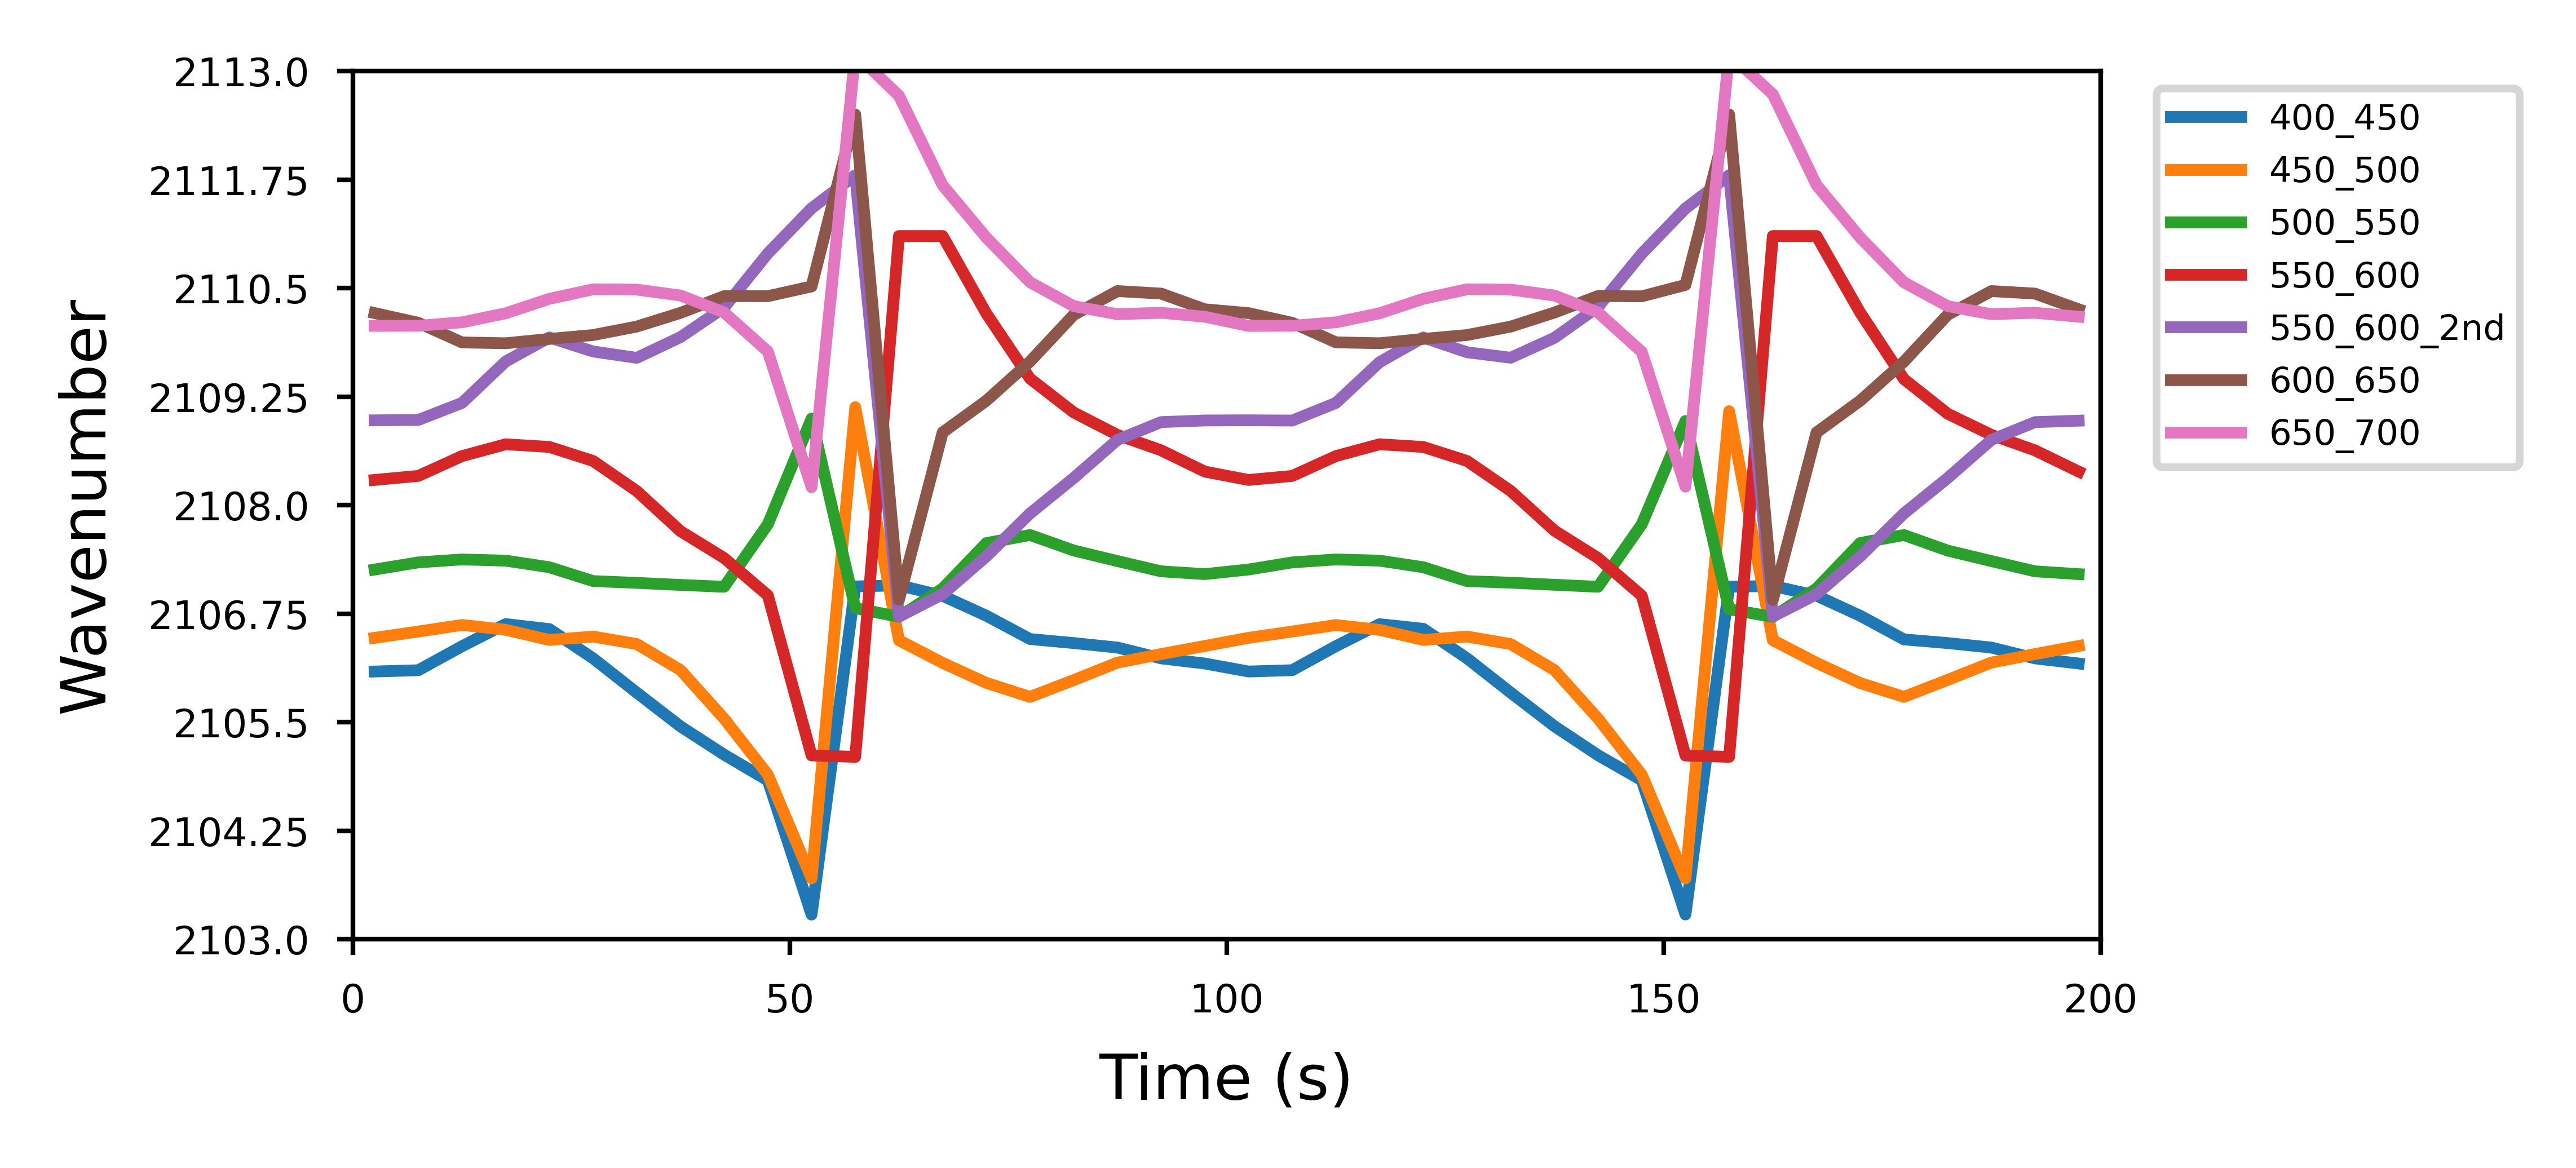

In [53]:

#The plotting proper fig
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = 'Plot_FTIR_241027_CuAl2O3_Anneal_CO_100ppm_200s5s_splitBest_Fit2000_2200locations'

plt.figure( linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(4, 2), linewidth = 0.6*font_size)

#ax.plot(area_plot[0][0].index.to_list(), area_plot[0][0].iloc[:,0].values, label=area_plot[0][1])
#peak= "lz3_"
#for space in df_areas.index.get_level_values(0).unique():
    #ax.plot(df_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_areas.loc[pd.IndexSlice[space,:],peak],label=space)
print(type(df_area_int))
#ax.plot(df_area_int.transpose(),label=df_area_int.transpose().columns,linewidth = 0.6*font_size,linestyle="none",marker=".",markersize=1*font_size)
colors=["navy","slategray","magenta"]
i=0
space = "500-550"
#for peak in df_area_int.transpose().columns:
    #ax.errorbar(df_area_int.transpose()[peak].index.to_numpy(),df_area_int.transpose()[peak].values,color = colors[i],label = peak,xerr=25,linewidth = 0.6*font_size,linestyle="none",marker=".",markersize=2*font_size,capsize= 1*font_size,elinewidth=0.4*font_size,capthick=0.4*font_size)
    #i+=1
for space in df_locations.index.get_level_values(0).unique():
    ax.plot(df_locations.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_locations.loc[pd.IndexSlice[space,:],peak]+(i*0.7),label=space)
    i+=1
#for peak in df_grad_areas.columns:   
    #ax.plot(df_grad_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_grad_areas.loc[pd.IndexSlice[space,:],peak],label=peak,color=colors[i],linewidth = 0.6*font_size,linestyle="-",marker=".",markersize=2*font_size)
    #i+=1
#Generation of the figure, change the figsize for the application you want (poster paper etc)


#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis



#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Time (s)", fontsize = 8*font_size)
ax.set_ylabel("Wavenumber", fontsize = 8*font_size)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=6*font_size)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 200 #High Range
xlow = 0 #Low Range
xpoints = 5 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
ax.set_xticks(xlabels)
ax.set_xticklabels(xlabels)
ax.set_xlim(xlow, xhigh)

#manual xlabels
#xlabels=[400,450,500,550,600,650,700]
#ax.set_xticks(xlabels)
#ax.set_xticklabels(xlabels)

#Adjusting range and tick frequency of y axis
yhigh = 2113 #High Range
ylow = 2103 #Low Range
ypoints = 9 #How many points you want on your axis
ydigits = 3 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]

print (ylabels)
ax.set_yticks(ylabels)
ax.set_yticklabels(ylabels)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 4.5*font_size, loc = "upper right", title_fontsize =4*font_size, bbox_to_anchor=(1.25, 1))
#plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()

In [128]:
slice_time=102.5
peak_set = []
xdat = df_data.loc[slice_time].loc["xdat",:]
ydat = df_data.loc[slice_time].loc["ydat",:]
best_fit = df_data.loc[slice_time].loc["best fit",:]
bkg = df_data.loc[slice_time].loc["bkg_",:]
for peak in df_data.loc[slice_time].iloc[4:,:].index:
    peak_set.append([peak,df_data.loc[slice_time].loc[peak,:]])


0
crimson lz1_
1
chocolate lz2_
2
slateblue lz3_
3
firebrick lz4_
[-0.0003, 8e-05, 0.00047, 0.00085, 0.00123, 0.00162, 0.002]
[-0.3, 0.08, 0.47, 0.85, 1.23, 1.62, 2.0]


<Figure size 640x480 with 0 Axes>

<Figure size 1066.67x800 with 0 Axes>

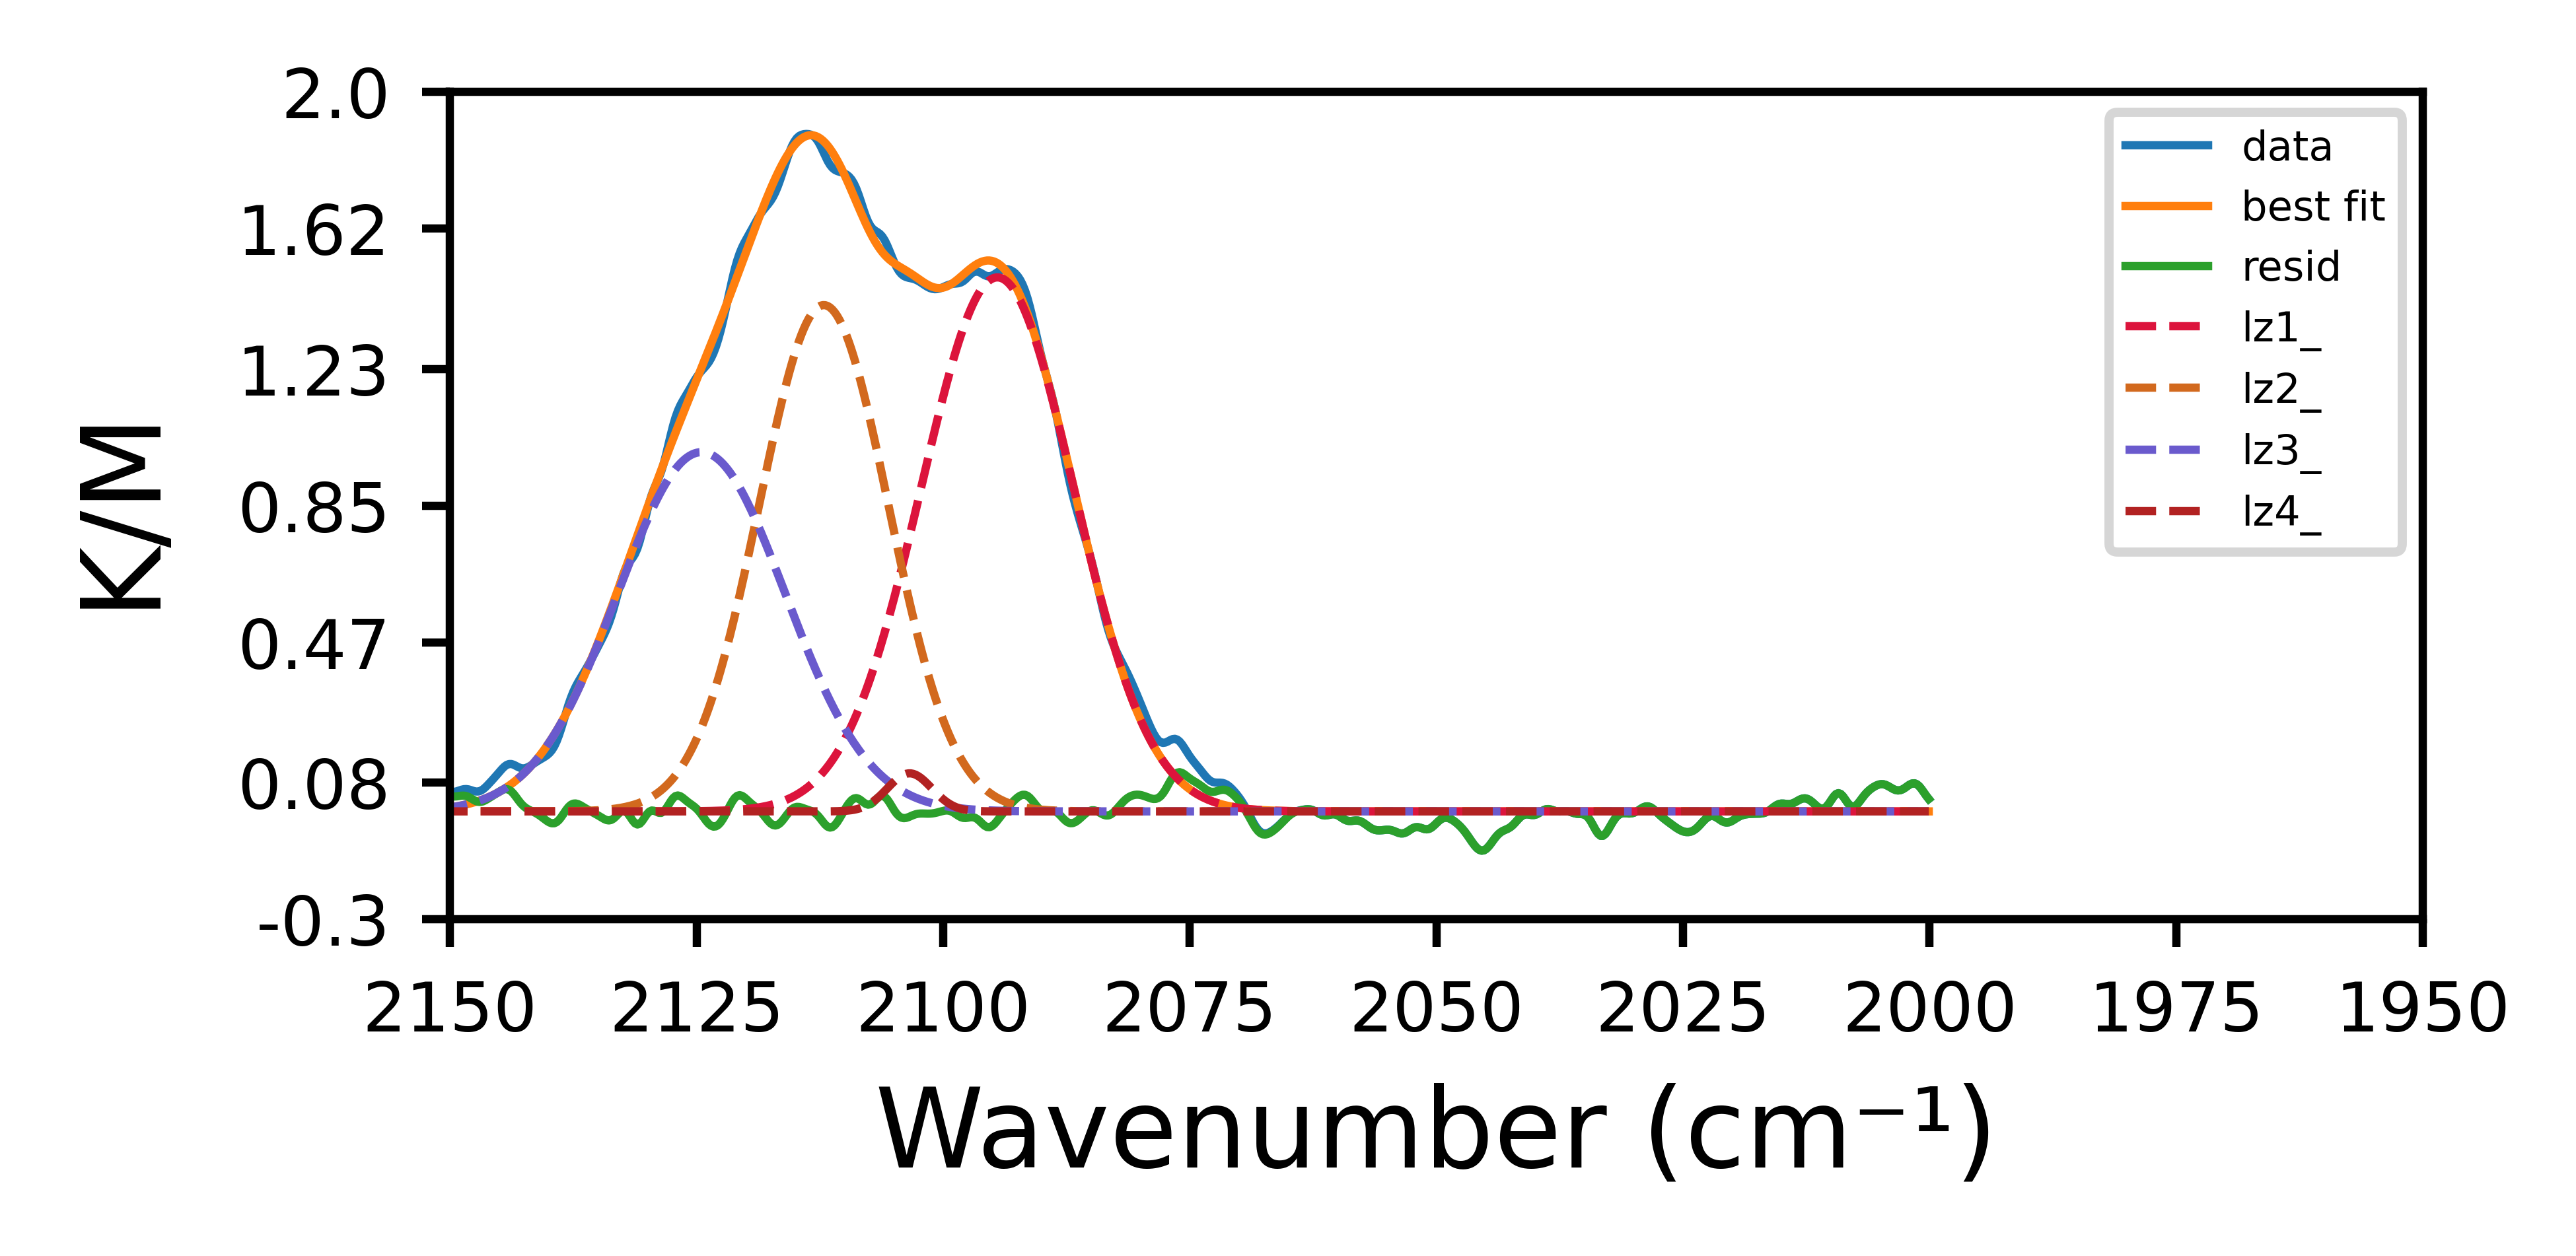

In [129]:
#The plotting proper fig
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1.5

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = '240911_CuAl2O3_100ppm_JDN2_28_CO_550_600_124mW_200s_2nd5s_splitBest_Fit_Values2000_2200V3'

plt.figure(linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(4, 2), linewidth = 0.6*font_size)
ax.plot(xdat, ydat-bkg, label='data',linewidth = 0.6*font_size)
ax.plot(xdat, best_fit-bkg, label='best fit',linewidth = 0.6*font_size)
ax.plot(xdat, ydat-best_fit, label='resid',linewidth = 0.6*font_size)
colors=["crimson","chocolate","slateblue","firebrick","black","slategray","magenta","darkturquoise"]#
i=0
for name, comp in peak_set:
    print(i)
    print(colors[i]+" " + name)
    
    ax.plot(xdat, comp, '--', label=name,linewidth = 0.6*font_size,color=colors[i])
    i+=1

#Generation of the figure, change the figsize for the application you want (poster paper etc)

#drift = table_for_plot.set_index('Wavenumber').plot(figsize=(3, 2), linewidth = 0.6*font_size, ax = ax,cmap = cmap)
#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis
plt.gca().invert_xaxis()


#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Wavenumber (cm" + get_super("-1") + ")", fontsize = 8*font_size,)
ax.set_ylabel("K/M", fontsize = 8*font_size,labelpad=6.9)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 2150 #High Range
xlow = 1950 #Low Range
xpoints = 9 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
ax.set_xticks(xlabels)
ax.set_xticklabels(xlabels)
ax.set_xlim(xhigh, xlow)

#Adjusting range and tick frequency of y axis
yhigh = 0.002 #High Range
ylow = -0.0003#Low Range
ypoints = 7 #How many points you want on your axis
ydigits = 5 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]
print (ylabels)

ax.set_yticks(ylabels)
for n,y in enumerate(ylabels):
    #ylabels[n] = format(y,'e').replace("0000","")
    ylabels[n] = round(y*1000,ydigits)
print (ylabels)
ax.set_yticklabels(ylabels)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 3*font_size, loc = "upper right", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()

[0, 20, 40, 60, 80, 100, 120]


<Figure size 640x480 with 0 Axes>

<Figure size 1066.67x800 with 0 Axes>

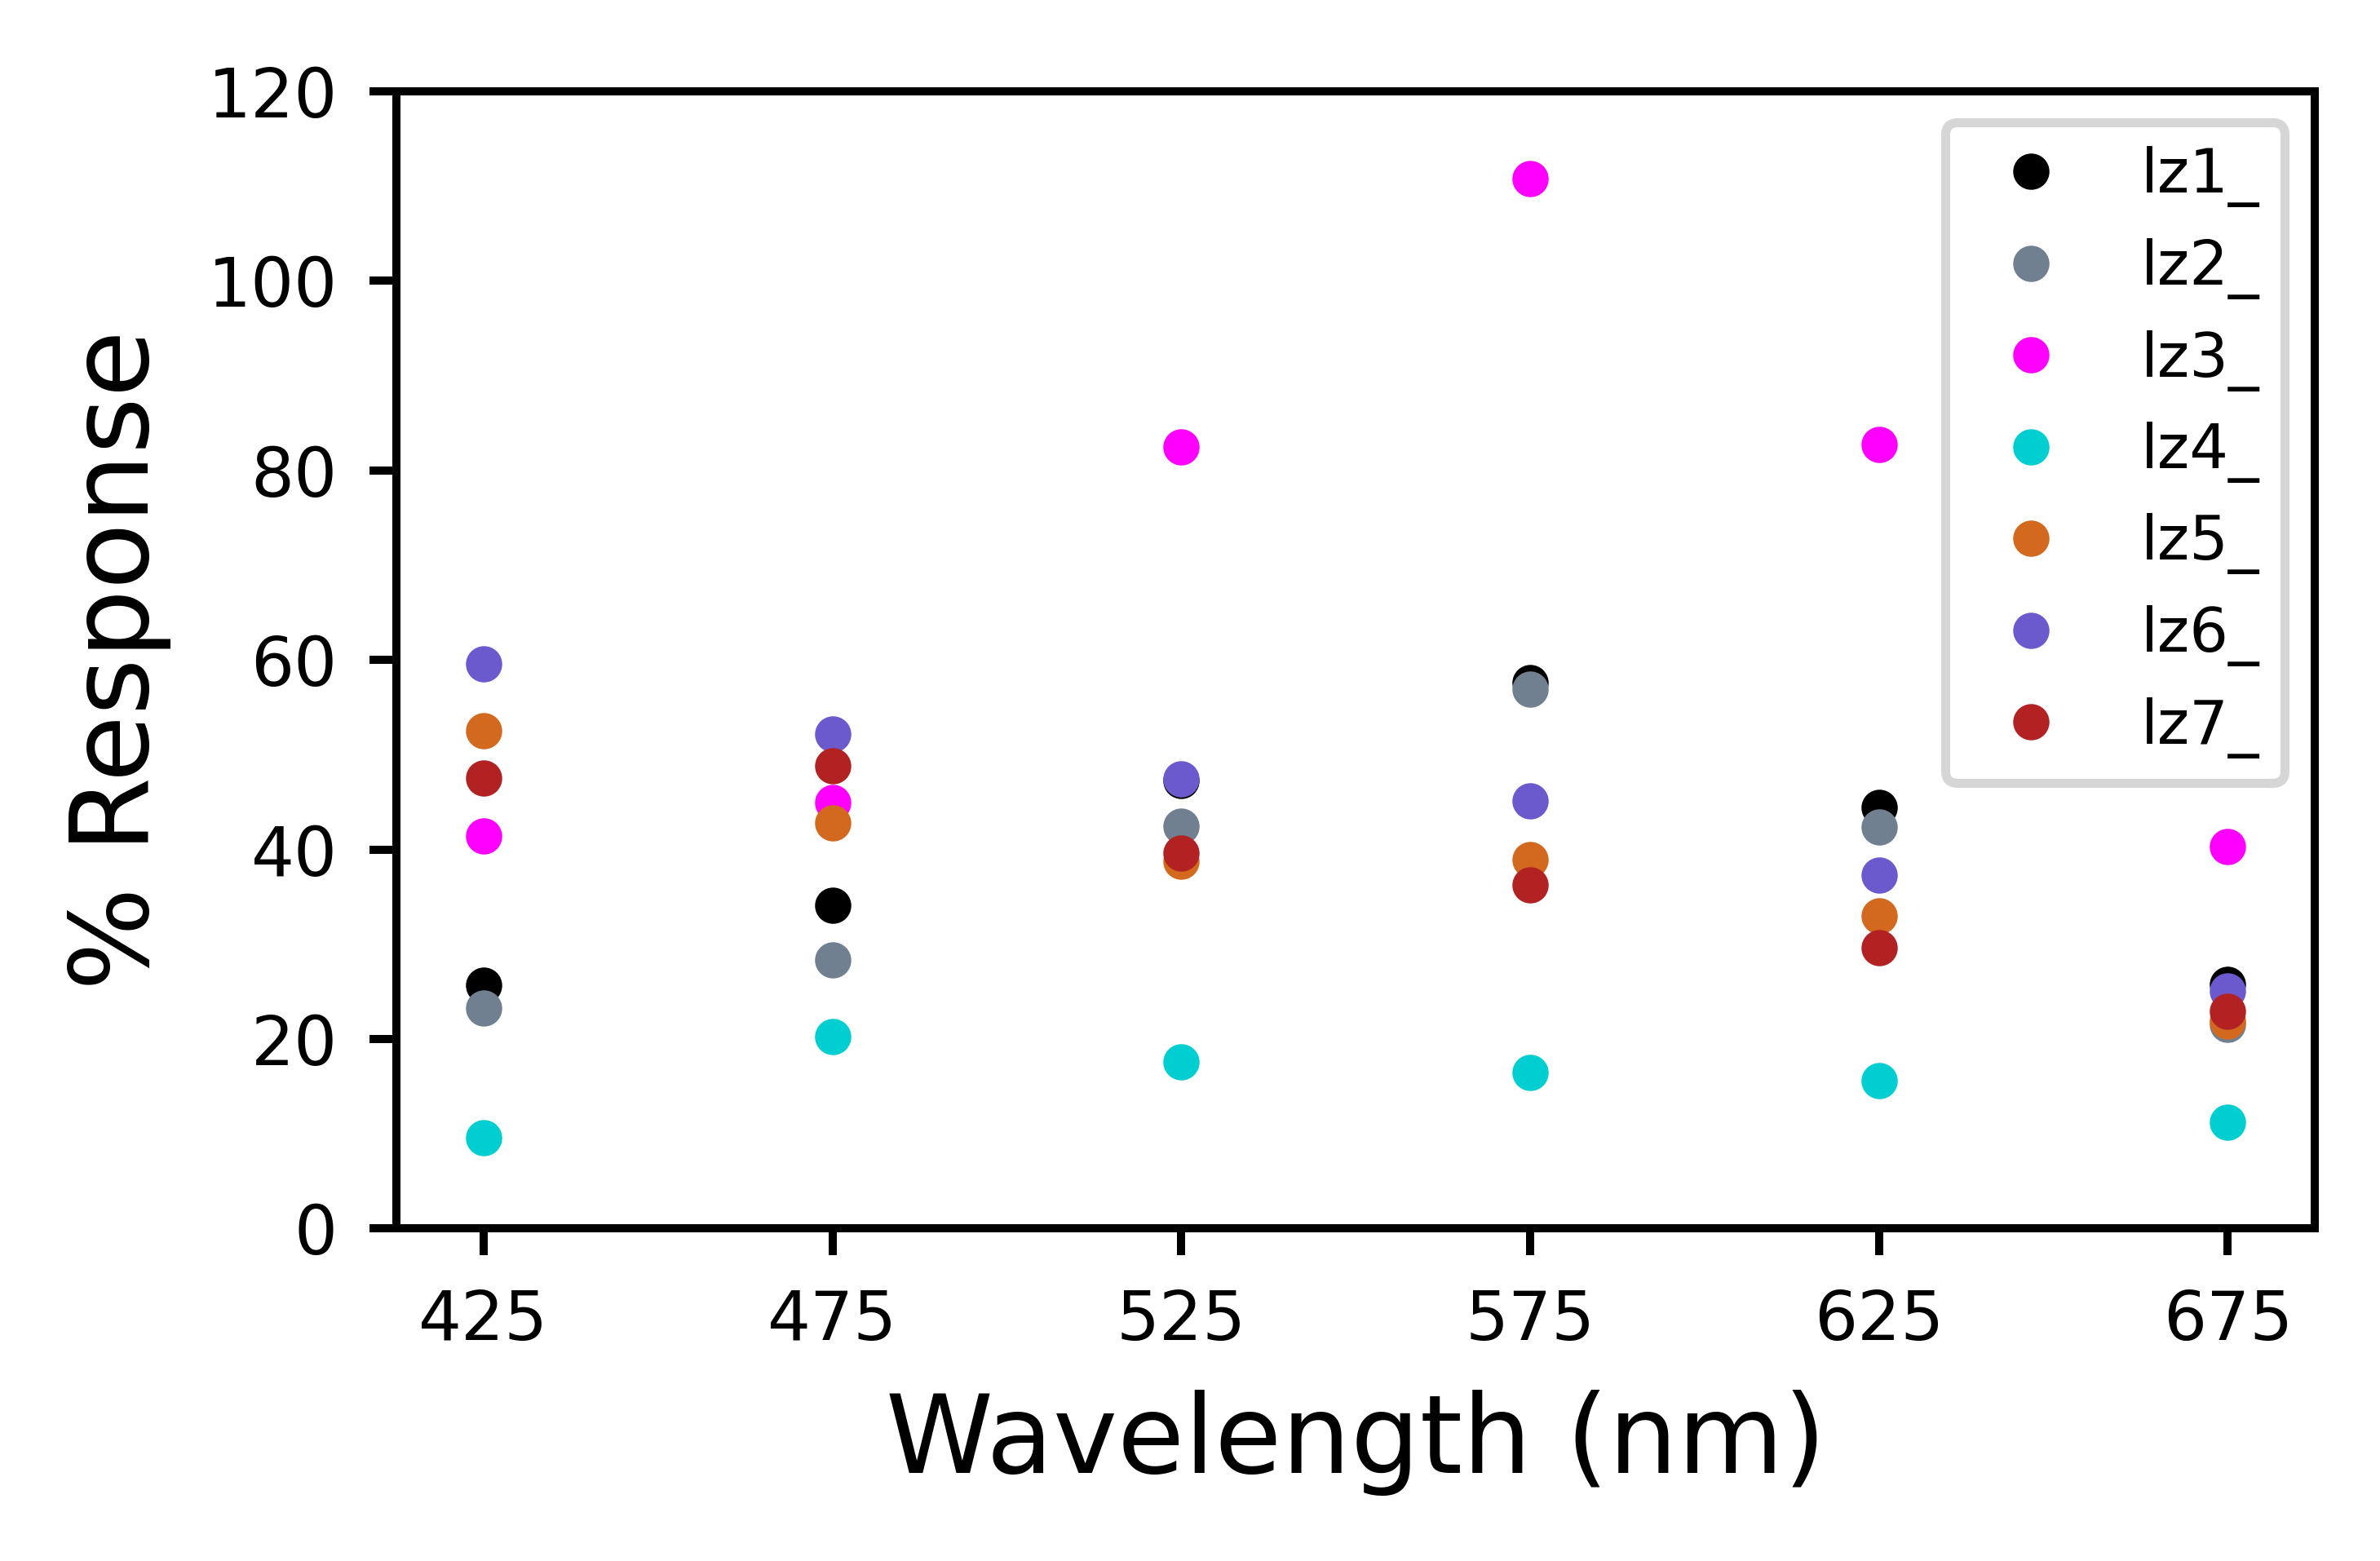

In [28]:

#The plotting proper fig
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1.5

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = 'FTIR_241107_CuAl2O3_Reduce_200s5s_splitBest_Fit1900_2150V4_wavelengthdepp_scalb4'

plt.figure( linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(3.75, 2.5), linewidth = 0.6*font_size)

colors=["black","slategray","magenta","darkturquoise","chocolate","slateblue","firebrick"]#"forestgreen"
ax.set_prop_cycle(color=colors) 
#ax.plot(df_area_int.transpose(),label=df_area_int.transpose().columns,linewidth = 0.6*font_size,linestyle="none",marker="none",markersize=1*font_size)

i=0
for peak in df_area_int_porp.transpose().columns:
    ax.errorbar(df_area_int_porp.transpose()[peak].index.to_numpy(),df_area_int_porp.transpose()[peak].values*100,color = colors[i],label = peak, linewidth = 0.6*font_size,linestyle="",marker=".",markersize=4*font_size,capsize= 1*font_size,elinewidth=0.4*font_size,capthick=0.4*font_size)
    #yerr=df_area_int_error.loc[peak,:]
    i+=1
#for space in df_areas.index.get_level_values(0).unique():
 #   ax.plot(df_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_areas.loc[pd.IndexSlice[space,:],peak],label=space)x
#Generation of the figure, change the figsize for the application you want (poster paper etc)


#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis



#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Wavelength (nm)", fontsize = 8*font_size)
ax.set_ylabel("% Response", fontsize = 8*font_size)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=6*font_size)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 200 #High Range
xlow = 80 #Low Range
xpoints = 5 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

#xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
#if xdigits <= 0:
    #xlabels = [int(num) for num in xlabels]
#ax.set_xticks(xlabels)
#ax.set_xticklabels(xlabels)
#ax.set_xlim(xlow, xhigh)

#manual xlabels
xlabels=[425,475,525,575,625,675]
ax.set_xticks(xlabels)
ax.set_xticklabels(xlabels)

#Adjusting range and tick frequency of y axis
yhigh = 120 #High Range
ylow = 0.00 #Low Range
ypoints = 7 #How many points you want on your axis
ydigits = 0 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]

print (ylabels)
ax.set_yticks(ylabels)
ax.set_yticklabels(ylabels)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 4.5*font_size, loc = "upper right", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name+"porp_b4_wr"), format='pdf')
plt.show()

[-0.03, -0.02, -0.01, 0.0, 0.01, 0.02, 0.03]


<Figure size 640x480 with 0 Axes>

<Figure size 1066.67x800 with 0 Axes>

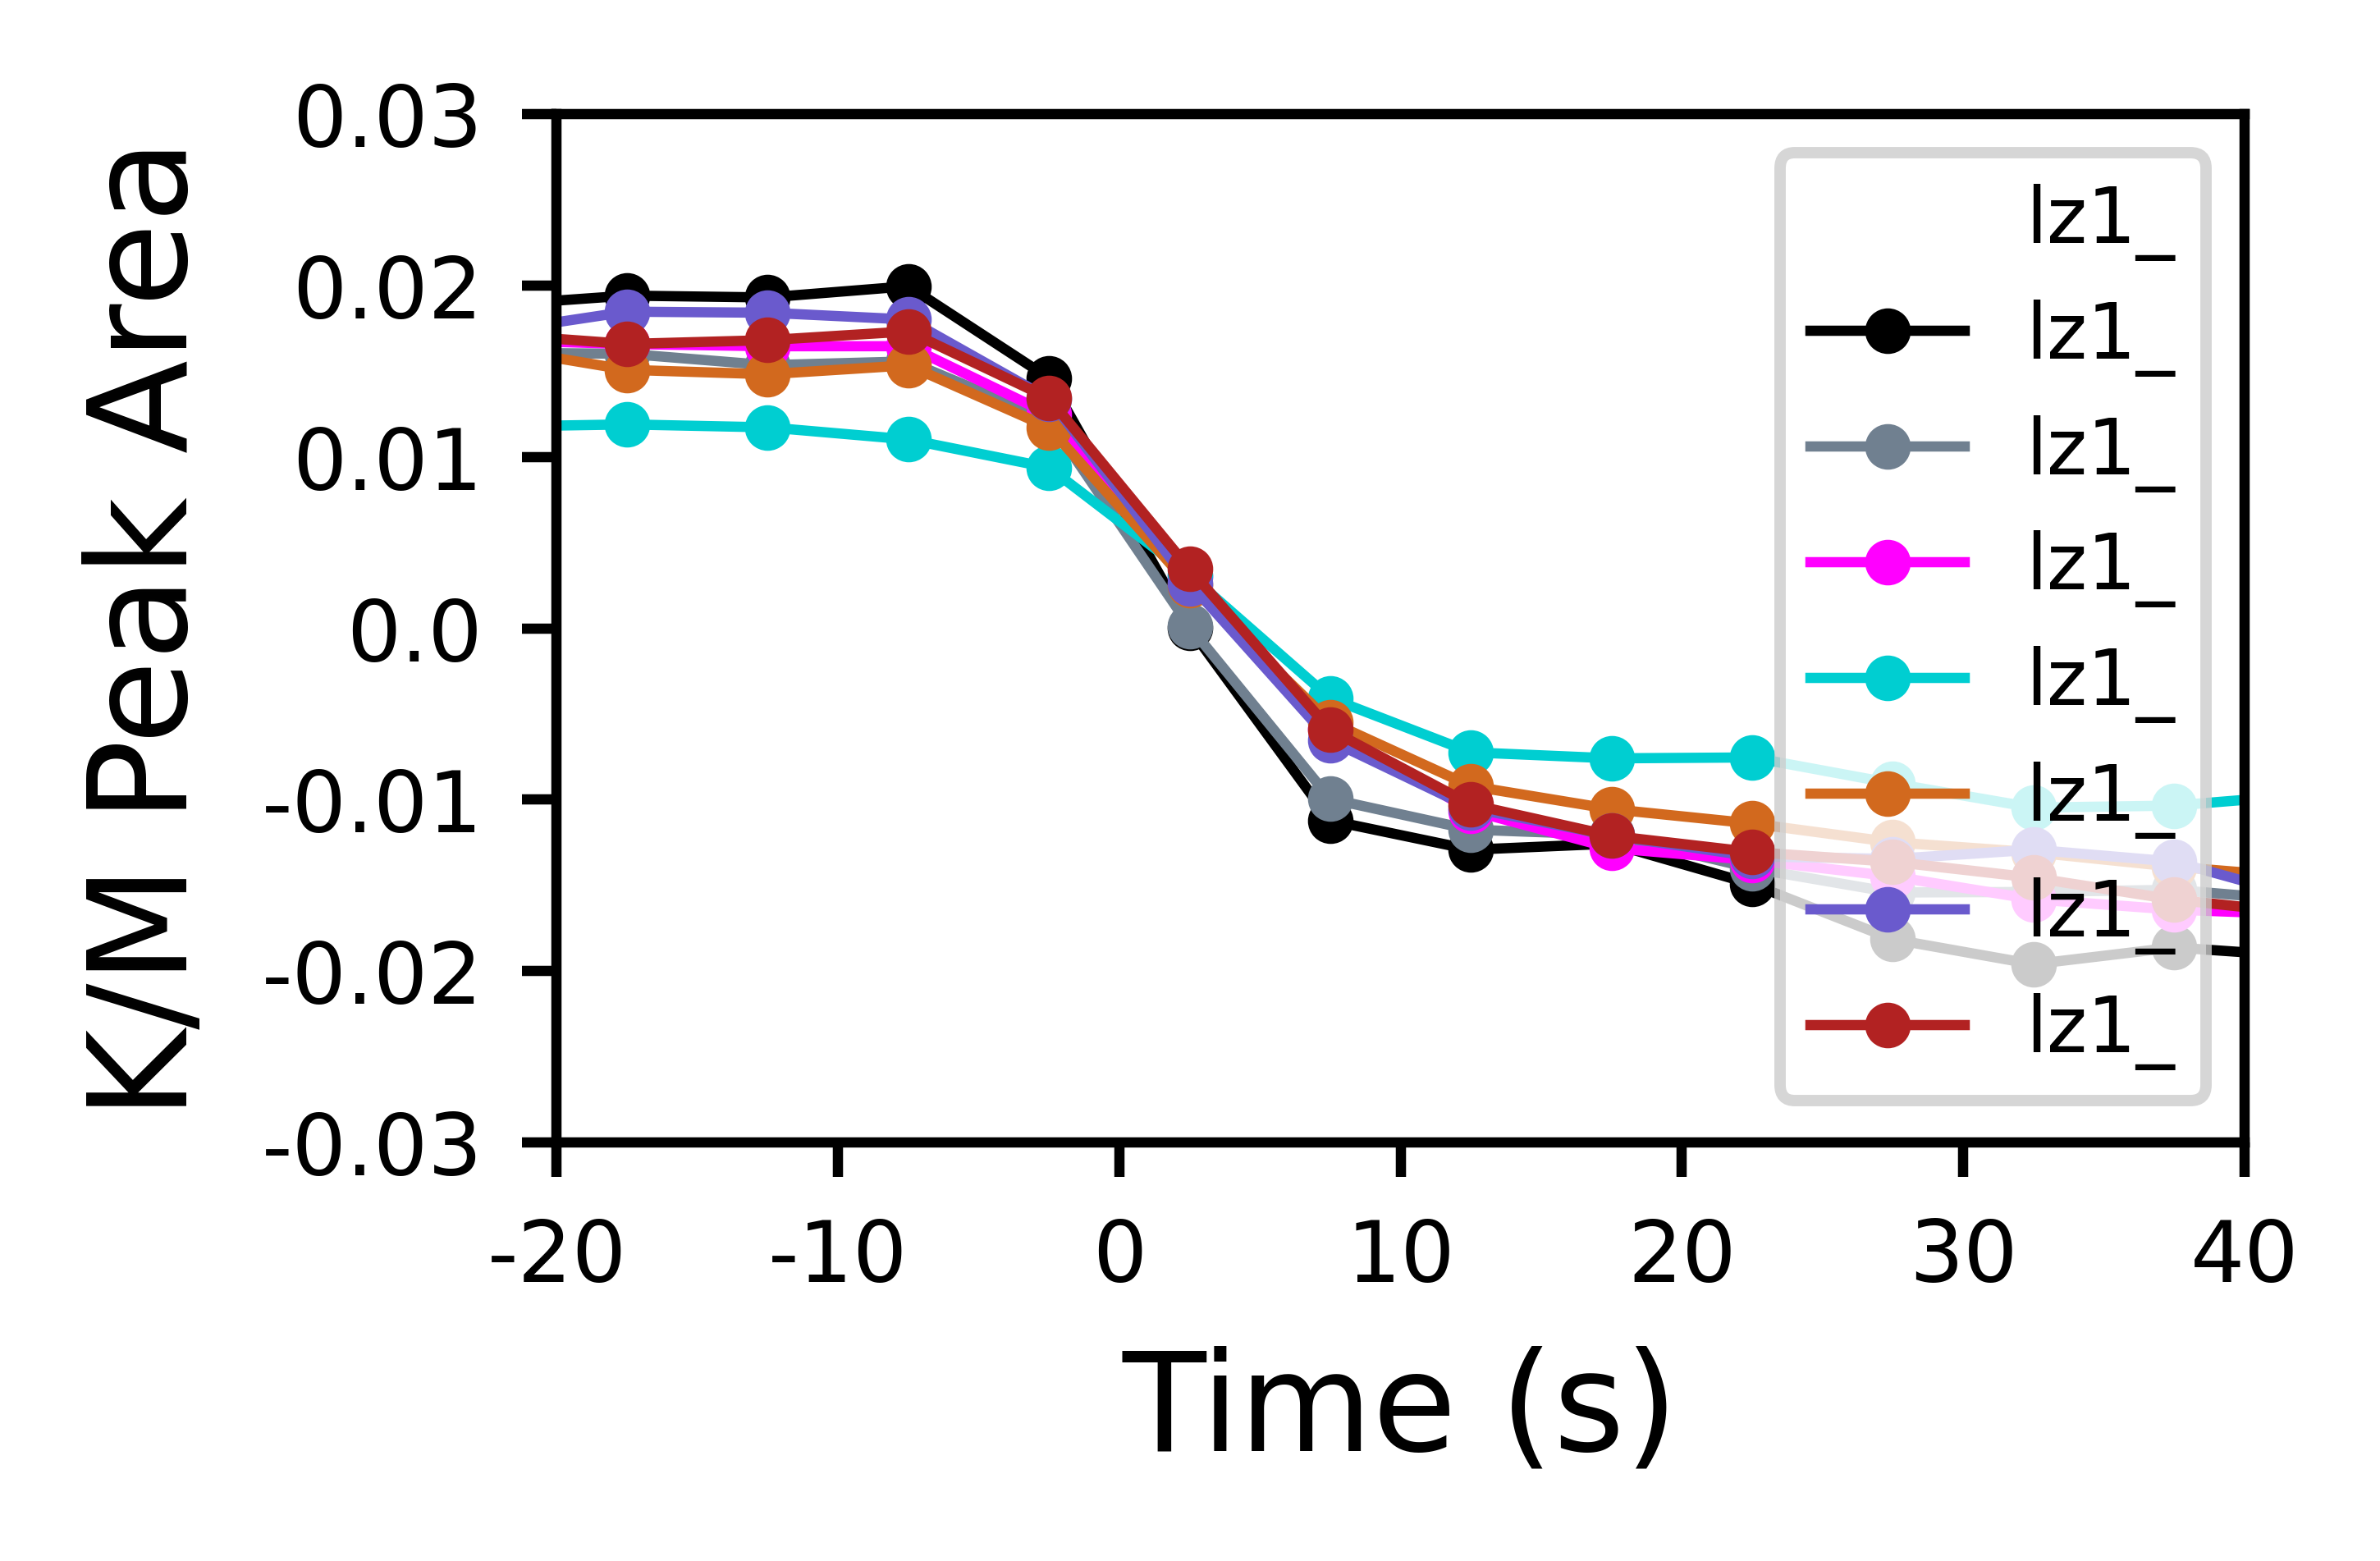

In [72]:

#The plotting proper fig
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1.5

cmap = mpl.colormaps['rainbow']
plt.set_cmap(cmap) 
#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'
area = "650_700"
#peak = "lz1_" 
#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
#fig_name = 'FTIR_241027_CuAl2O3_Anneal_CO_100ppm'+area+'_200s5s_splitBest_Fit2000_2200V3_grad_abbreviated'

plt.figure( linewidth = 0.6*font_size,dpi=250*(1/font_size))
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(3, 2), linewidth = 0.6*font_size)

colors=["black","slategray","magenta","darkturquoise","chocolate","slateblue","firebrick"]#"forestgreen"
ax.set_prop_cycle(color=colors) 
ax.plot(df_area_int.transpose(),label=df_area_int.transpose().columns,linewidth = 0.6*font_size,linestyle="none",marker="none",markersize=1*font_size)

i=0

#for peak in df_grad_areas.columns:
for area in df_grad_areas.index.get_level_values(0).unique():
    if i == 0:
        standard = np.mean(np.absolute(df_grad_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()))
    scale = standard/np.mean(np.absolute(df_grad_areas.loc[pd.IndexSlice[space,:],peak].to_numpy()))
    #ax.plot(df_grad_areas[peak][area].index.to_numpy(),df_grad_areas[peak][area].values*scale,color = colors[i],label = area, linewidth = 0.6*font_size,linestyle="-",marker=".",markersize=4*font_size)
    ax.plot(df_grad_areas[peak][area].index.to_numpy(),df_grad_areas[peak][area].values,color = colors[i],label = peak, linewidth = 0.6*font_size,linestyle="-",marker=".",markersize=4*font_size)
    #yerr=df_area_int_error.loc[peak,:]
    i+=1
#for space in df_areas.index.get_level_values(0).unique():
 #   ax.plot(df_areas.loc[pd.IndexSlice[space,:],:].index.get_level_values(1),df_areas.loc[pd.IndexSlice[space,:],peak],label=space)x
#Generation of the figure, change the figsize for the application you want (poster paper etc)


#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis



#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Time (s)", fontsize = 8*font_size)
ax.set_ylabel("K/M Peak Area", fontsize = 8*font_size)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=6*font_size)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 140 #High Range
xlow = 80 #Low Range
xpoints = 7 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
ax.set_xticks(xlabels)
for i in range(len(xlabels)):
    xlabels[i] = xlabels[i]-100
ax.set_xticklabels(xlabels)
ax.set_xlim(xlow, xhigh)



#Adjusting range and tick frequency of y axis
yhigh = 0.03 #High Range
ylow = -0.03 #Low Range
ypoints = 7 #How many points you want on your axis
ydigits = 4 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]

print (ylabels)
ax.set_yticks(ylabels)
ax.set_yticklabels(ylabels)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 4.5*font_size, loc = "upper right", title_fontsize =4*font_size)#, bbox_to_anchor=(1, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()

In [14]:
#Get rates at cetain timepoints
df_grad_rates = df_grad_areas.copy()
kernel_size = 1
kernel = np.ones(kernel_size) / kernel_size
for space in df_grad_rates.index.get_level_values(0).unique()[:]:
    for peak in df_grad_rates.columns:
        np_temp = df_grad_rates.loc[pd.IndexSlice[space,:],peak].to_numpy()
        np_temp =np.gradient(np_temp,5,edge_order=1)
        df_grad_rates.loc[pd.IndexSlice[space,:],peak] = np_temp
df_grad_rates.loc[pd.IndexSlice[:,(102.5,112.5,122.5,132.5)],:]

lz1_      lz2_          lz3_          lz4_      lz5_      lz6_  \
425 102.5 -0.001933 -0.000761 -5.502787e-04 -1.587928e-04 -0.002643 -0.001849   
    112.5 -0.000573 -0.000250 -3.458513e-04 -3.278971e-05 -0.001664 -0.000865   
    122.5 -0.000249 -0.000207  6.991290e-05  8.196566e-05 -0.000721 -0.000629   
    132.5  0.000077  0.000085  4.879579e-05  9.565098e-05 -0.000222 -0.000186   
475 102.5 -0.002618 -0.000984 -7.059103e-04 -4.711517e-05 -0.001974 -0.001867   
    112.5 -0.000589 -0.000210 -2.866694e-04  9.713002e-05 -0.001232 -0.000726   
    122.5 -0.000243 -0.000183  5.462255e-05 -2.234075e-04 -0.001013 -0.000650   
    132.5 -0.000182 -0.000164  7.227107e-07  9.860980e-07 -0.000073 -0.000197   
525 102.5 -0.003770 -0.001428 -9.870761e-04 -2.049075e-04 -0.001672 -0.001264   
    112.5 -0.000652 -0.000401 -2.931629e-04 -2.664998e-05 -0.001268 -0.000858   
    122.5 -0.000330 -0.000133  1.645559e-05  5.346159e-05 -0.000583 -0.000414   
    132.5 -0.000212 -0.000176  1.965566e-05 -1.152644e-04 -0.000498 -0.000313   
575 102.5 -0.004727 -0.001871 -1.563197e-03  7.926161e-06 -0.001367 -0.001298   
    112.5 -0.000949 -0.000485 -2.653339e-04 -2.246691e-04 -0.001532 -0.001005   
    122.5 -0.000329 -0.000273 -1.492658e-04 -1.902812e-04 -0.000819 -0.000480   
    132.5 -0.000206 -0.000268  2.183774e-05 -5.458491e-05 -0.000422 -0.000405   
625 102.5 -0.003551 -0.001500 -1.117893e-03 -9.116109e-05 -0.001037 -0.000945   
    112.5 -0.000968 -0.000350 -3.381226e-05 -4.843538e-05 -0.001360 -0.000910   
    122.5 -0.000252 -0.000229 -2.610465e-04 -1.317808e-04 -0.000746 -0.000479   
    132.5 -0.000081 -0.000114  5.163773e-05 -2.322811e-05 -0.000187 -0.000100   
675 102.5 -0.001929 -0.000799 -5.092229e-04  4.850121e-05 -0.000463 -0.000468   
    112.5 -0.000432 -0.000234  5.126279e-05 -1.097389e-04 -0.000813 -0.000824   
    122.5 -0.000294 -0.000137 -4.215159e-05 -1.610384e-05 -0.000542 -0.000225   
    132.5 -0.000050 -0.000015 -3.367551e-05 -1.227584e-04 -0.000246  0.000045   

               lz7_  
425 102.5 -0.000740  
    112.5 -0.000633  
    122.5 -0.000337  
    132.5  0.000168  
475 102.5 -0.000613  
    112.5 -0.000601  
    122.5 -0.000278  
    132.5 -0.000203  
525 102.5 -0.000496  
    112.5 -0.000384  
    122.5 -0.000333  
    132.5 -0.000073  
575 102.5 -0.000420  
    112.5 -0.000471  
    122.5 -0.000374  
    132.5 -0.000257  
625 102.5 -0.000209  
    112.5 -0.000566  
    122.5 -0.000394  
    132.5 -0.000002  
675 102.5 -0.000010  
    112.5 -0.000420  
    122.5 -0.000276  
    132.5 -0.000192